# **01. Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# **02. Load Dataset**

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Datasets/ROSIDS23.csv"
df = pd.read_csv(DATASET_PATH)

# **03. Dataset Overview**

In [ ]:
df.shape

(136681, 84)

In [ ]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.4-192.168.3.6-11311-60792-6,192.168.3.6,60792,192.168.3.4,11311,6,07/07/2023 02:10:23 PM,6260,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,192.168.3.4-192.168.3.6-11311-60794-6,192.168.3.6,60794,192.168.3.4,11311,6,07/07/2023 02:10:23 PM,5903,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,192.168.3.4-192.168.3.6-11311-39922-6,192.168.3.6,39922,192.168.3.4,11311,6,07/07/2023 02:10:32 PM,4523,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,192.168.3.4-192.168.3.6-11311-55266-6,192.168.3.6,55266,192.168.3.4,11311,6,07/07/2023 02:11:11 PM,5191,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,192.168.3.6-192.168.3.7-43770-11111-6,192.168.3.7,11111,192.168.3.6,43770,6,07/07/2023 02:10:03 PM,72625778,2200,2212,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [ ]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

In [ ]:
df.dtypes

,0
Flow ID,object
Src IP,object
Src Port,int64
Dst IP,object
Dst Port,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,float64
Idle Min,float64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Flow ID,0
Src IP,0
Src Port,0
Dst IP,0
Dst Port,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
df["Label"].value_counts()

,count
Label,
Benign,62511
DoS,31000
Subflood,30064
UnauthPub,7817
UnauthSub,5289


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Src Port,136681.0,3.539043e+04,1.756249e+04,0.0,11311.0,38984.0,49178.0,6.553500e+04
Dst Port,136681.0,2.792530e+04,2.060046e+04,0.0,11311.0,35222.0,44930.0,6.541800e+04
Protocol,136681.0,6.065203e+00,9.652164e-01,0.0,6.0,6.0,6.0,1.700000e+01
Flow Duration,136681.0,3.093967e+07,3.490355e+07,0.0,4123.0,508341.0,58780722.0,1.200000e+08
Tot Fwd Pkts,136681.0,5.930385e+02,5.018832e+03,0.0,1.0,5.0,33.0,1.192570e+05
...,...,...,...,...,...,...,...,...
Active Min,136681.0,2.777034e+06,8.853524e+06,0.0,0.0,0.0,268.0,1.129778e+08
Idle Mean,136681.0,6.463119e+06,1.596497e+07,0.0,0.0,0.0,5525405.0,1.196444e+08
Idle Std,136681.0,1.126476e+06,4.999828e+06,0.0,0.0,0.0,0.0,4.755196e+07
Idle Max,136681.0,7.469949e+06,1.776872e+07,0.0,0.0,0.0,5744825.0,1.196444e+08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136681 entries, 0 to 136680
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            136681 non-null  object 
 1   Src IP             136681 non-null  object 
 2   Src Port           136681 non-null  int64  
 3   Dst IP             136681 non-null  object 
 4   Dst Port           136681 non-null  int64  
 5   Protocol           136681 non-null  int64  
 6   Timestamp          136681 non-null  object 
 7   Flow Duration      136681 non-null  int64  
 8   Tot Fwd Pkts       136681 non-null  int64  
 9   Tot Bwd Pkts       136681 non-null  int64  
 10  TotLen Fwd Pkts    136681 non-null  float64
 11  TotLen Bwd Pkts    136681 non-null  float64
 12  Fwd Pkt Len Max    136681 non-null  float64
 13  Fwd Pkt Len Min    136681 non-null  float64
 14  Fwd Pkt Len Mean   136681 non-null  float64
 15  Fwd Pkt Len Std    136681 non-null  float64
 16  Bw

# **04. Exploratory Data Analysis**

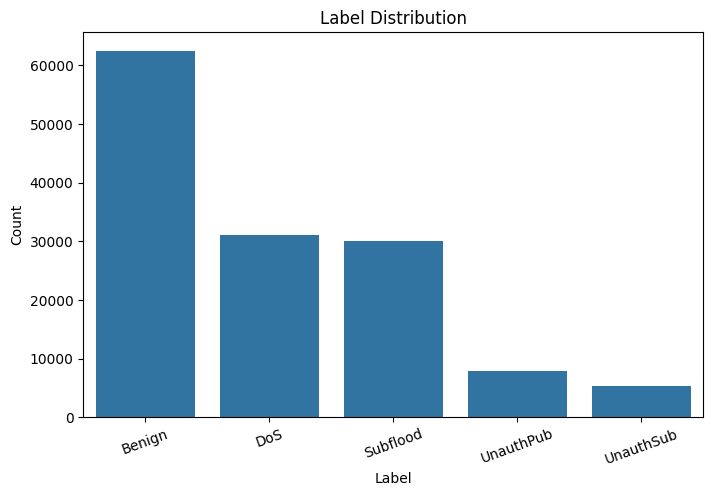

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [ ]:
df["Label"].value_counts(normalize=True).mul(100).round(2)

,proportion
Label,
Benign,45.73
DoS,22.68
Subflood,22.00
UnauthPub,5.72
UnauthSub,3.87


## ***Object/categorical columns***

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
  print(f"\n{col}")
  print("Unique Values: ", df[col].nunique())
  print(df[col].head(3))


Flow ID
Unique Values:  71793
0    192.168.3.4-192.168.3.6-11311-60792-6
1    192.168.3.4-192.168.3.6-11311-60794-6
2    192.168.3.4-192.168.3.6-11311-39922-6
Name: Flow ID, dtype: object

Src IP
Unique Values:  6
0    192.168.3.6
1    192.168.3.6
2    192.168.3.6
Name: Src IP, dtype: object

Dst IP
Unique Values:  9
0    192.168.3.4
1    192.168.3.4
2    192.168.3.4
Name: Dst IP, dtype: object

Timestamp
Unique Values:  13625
0    07/07/2023 02:10:23 PM
1    07/07/2023 02:10:23 PM
2    07/07/2023 02:10:32 PM
Name: Timestamp, dtype: object

Label
Unique Values:  5
0    Benign
1    Benign
2    Benign
Name: Label, dtype: object


## ***Numerical feature quality***

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
print("No of Numerical Features: ", len(numeric_cols))
print("Infinite Values: ", np.isinf(df[numeric_cols]).sum().sum()) # check infinit values
print("Zero Variance: ", (df[numeric_cols].nunique() <= 1).sum())

No of Numerical Features:  79
Infinite Values:  278
Zero Variance:  14


## ***Investigate Zero Varience Features***

In [ ]:
zero_variance_cols = numeric_cols[df[numeric_cols].nunique() <= 1]
print("Zero Variance Features: \n", zero_variance_cols.tolist())

Zero Variance Features: 
 ['Fwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


## ***Investigate Infinite Values***

In [ ]:
inf_counts = pd.Series(
    np.isinf(df[numeric_cols]).sum(),
    index = numeric_cols

)
print("Infinite values columns: \n", inf_counts[inf_counts > 0])

Infinite values columns: 
 Flow Byts/s      3
Flow Pkts/s    275
dtype: int64


## ***Remove Zero Variance Features and Replace Infinity***

In [ ]:
df_clean = df.drop(columns=zero_variance_cols).copy()

df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("Missing values after inf replace: ")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after inf replace: 
Flow Byts/s    275
Flow Pkts/s    275
dtype: int64


## ***Remove rows that has missing values***

In [ ]:
df_clean = df_clean.dropna()

print("New shape: ", df_clean.shape)
print("Missing values: ", df_clean.isnull().sum().sum())

New shape:  (136406, 70)
Missing values:  0


# **05. Data Pre-Processing**

## ***Separate X and y***

In [ ]:
exclude_cols = [
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Label"
]
X = df_clean.drop(columns=exclude_cols)
y = df_clean["Label"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (136406, 65)
y shape:  (136406,)


In [ ]:
print("Features: \n", X.columns.tolist())

Features: 
 ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'A

## ***Encode the Labels***

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
print("Classes: ", label_encoder.classes_)
print("Encoded: ", np.unique(y_encoded))

Classes:  ['Benign' 'DoS' 'Subflood' 'UnauthPub' 'UnauthSub']
Encoded:  [0 1 2 3 4]


## ***Train / Test Split***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size = 0.2,
    random_state = 42,
    stratify = y_encoded
)

print("Training: ", X_train.shape)
print("Testing: ", X_test.shape)

Training:  (109124, 65)
Testing:  (27282, 65)


## ***Scale the Features***

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (109124, 65)
Scaled testing shape: (27282, 65)


In [ ]:
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())

Mean: -3.883759881548878e-18
Std: 0.9999999999999998


# **06. Deep Learning Model**

## ***Build an MLP Model***

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,469 (25.27 KB)

 Trainable params: 6,469 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

## ***Train Model***

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8967 - loss: 0.3501 - val_accuracy: 0.9168 - val_loss: 0.2734
Epoch 2/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9156 - loss: 0.2744 - val_accuracy: 0.9193 - val_loss: 0.2551
Epoch 3/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9225 - loss: 0.2440 - val_accuracy: 0.9394 - val_loss: 0.2141
Epoch 4/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9344 - loss: 0.2148 - val_accuracy: 0.9419 - val_loss: 0.1892
Epoch 5/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9413 - loss: 0.1938 - val_accuracy: 0.9621 - val_loss: 0.1648
Epoch 6/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9523 - loss: 0.1734 - val_accuracy: 0.9633 - val_loss: 0.1503
Epoch 7/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9585 - loss: 0.1607 - val_accuracy: 0.9637 - val_loss: 0.1459
Epoch 8/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9614 - loss: 0.1531 - 

## ***Plot Training Behavior***

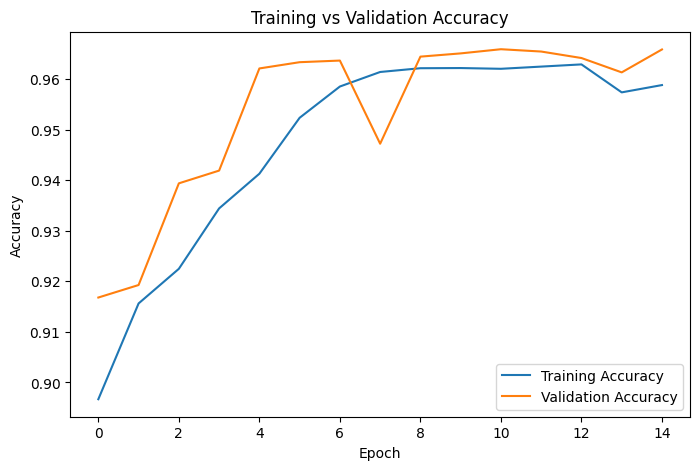

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

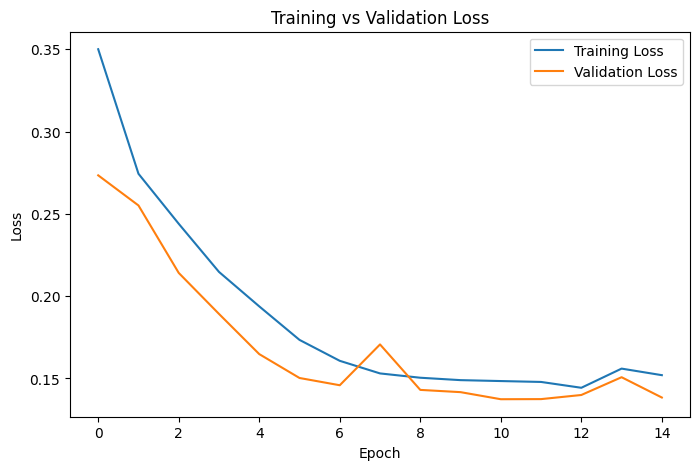

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## ***Test Performance***

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.1464676856994629
Test Accuracy: 0.9638223052024841


## ***Prediction Generation***

In [ ]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

853/853 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## **Calculate the Result**

In [ ]:
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Precision: 0.9635624157066079
Recall: 0.9638223004178579
F1 Score: 0.9634114684642813


In [ ]:
print("\nClass-wise report:")
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


Class-wise report:
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97     12457
         DoS       1.00      1.00      1.00      6200
    Subflood       0.99      0.96      0.98      6013
   UnauthPub       0.88      0.88      0.88      1563
   UnauthSub       0.84      0.74      0.79      1049

    accuracy                           0.96     27282
   macro avg       0.93      0.91      0.92     27282
weighted avg       0.96      0.96      0.96     27282



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm,
#     display_labels=label_encoder.classes_
# )

# fig, ax = plt.subplots(figsize=(8, 6))
# disp.plot(ax=ax, xticks_rotation=30)
# plt.title("Confusion Matrix - MLP")
# plt.show()

[[12190     0    43   129    95]
 [    2  6198     0     0     0]
 [  211     0  5764    34     4]
 [  145     0     1  1370    47]
 [  258     0     2    16   773]]


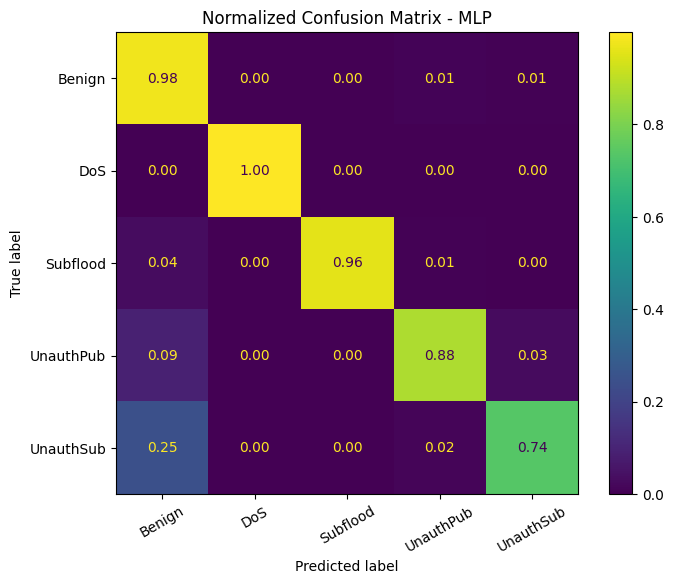

In [ ]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize='true'
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=30, values_format=".2f")
plt.title("Normalized Confusion Matrix - MLP")
plt.show()

In [ ]:
cm_normalized

array([[9.78566268e-01, 0.00000000e+00, 3.45187445e-03, 1.03556233e-02,
        7.62623425e-03],
       [3.22580645e-04, 9.99677419e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [3.50906370e-02, 0.00000000e+00, 9.58589722e-01, 5.65441543e-03,
        6.65225345e-04],
       [9.27703135e-02, 0.00000000e+00, 6.39795266e-04, 8.76519514e-01,
        3.00703775e-02],
       [2.45948522e-01, 0.00000000e+00, 1.90657769e-03, 1.52526215e-02,
        7.36892278e-01]])

# **07. Machine Learning Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy Score: ",accuracy_score(y_test, rf_pred) )

print("Classification Report: ")
print(
    classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_
)
)


Accuracy Score:  0.9770178139432593
Classification Report: 
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.98     12457
         DoS       1.00      1.00      1.00      6200
    Subflood       0.99      0.98      0.98      6013
   UnauthPub       0.92      0.93      0.92      1563
   UnauthSub       0.90      0.89      0.90      1049

    accuracy                           0.98     27282
   macro avg       0.96      0.96      0.96     27282
weighted avg       0.98      0.98      0.98     27282



In [ ]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[12198     0    65   123    71]
 [    1  6198     1     0     0]
 [  131     0  5873     1     8]
 [   92     0     0  1451    20]
 [  101     0     6     7   935]]


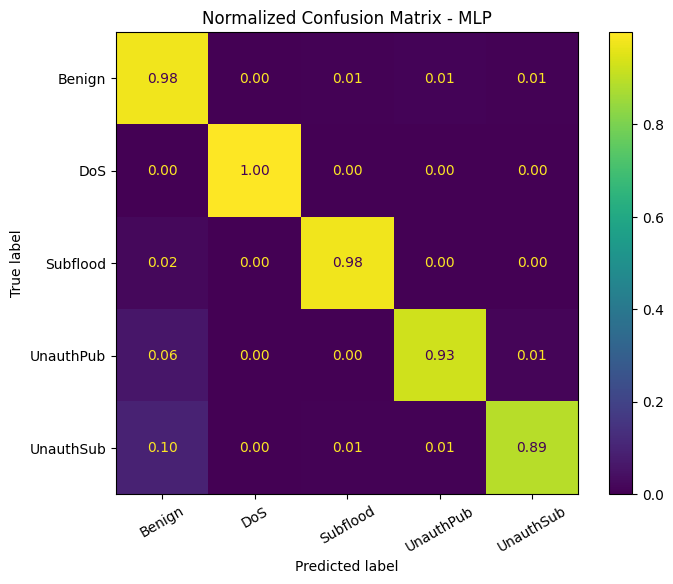

[[9.79208477e-01 0.00000000e+00 5.21794975e-03 9.87396644e-03
  5.69960665e-03]
 [1.61290323e-04 9.99677419e-01 1.61290323e-04 0.00000000e+00
  0.00000000e+00]
 [2.17861301e-02 0.00000000e+00 9.76717113e-01 1.66306336e-04
  1.33045069e-03]
 [5.88611644e-02 0.00000000e+00 0.00000000e+00 9.28342930e-01
  1.27959053e-02]
 [9.62821735e-02 0.00000000e+00 5.71973308e-03 6.67302193e-03
  8.91325071e-01]]


In [ ]:
cm_normalized = confusion_matrix(
    y_test,
    rf_pred,
    normalize='true'
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=30, values_format=".2f")
plt.title("Normalized Confusion Matrix - MLP")
plt.show()
print(cm_normalized)

## ***Feature Importance***

In [ ]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

Dst Port             0.074084
Fwd IAT Min          0.066328
Init Bwd Win Byts    0.064013
Bwd Header Len       0.062586
Bwd IAT Max          0.049715
Fwd IAT Std          0.049086
Tot Bwd Pkts         0.046595
Bwd IAT Mean         0.041017
Fwd IAT Max          0.038332
Fwd IAT Mean         0.029399
Subflow Bwd Pkts     0.028279
Bwd IAT Tot          0.027819
Fwd IAT Tot          0.024865
Flow IAT Std         0.024062
Flow Pkts/s          0.021672
dtype: float64


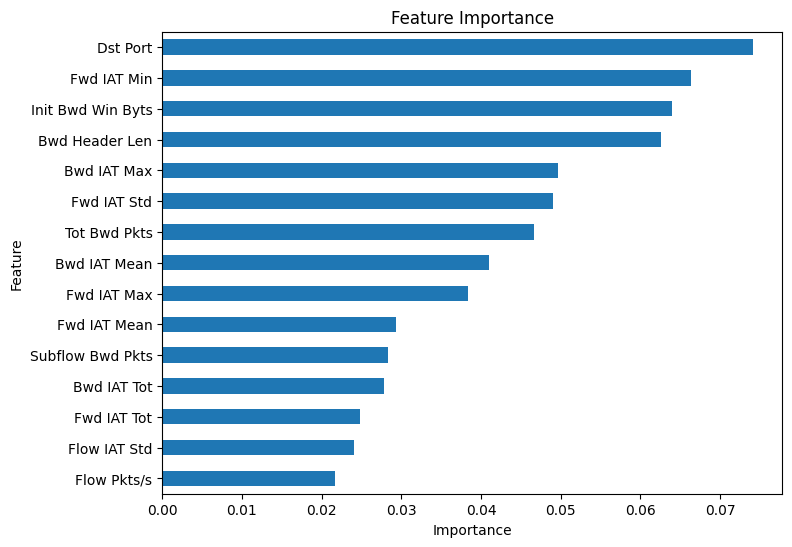

In [ ]:
plt.figure(figsize=(8,6))

feature_importance.head(15).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# **08. Outcome**

In this phase of the study, the ROSIDS23 dataset was thoroughly explored and preprocessed to ensure data quality. Following the data cleaning, baseline classification experiments were conducted using Multi-Layer Perceptron (MLP) and Random Forest models. The Random Forest model outperformed the MLP, achieving a test accuracy of 97.70% compared to the MLP’s 96.38%. Notably, the MLP struggled to accurately classify the 'UnauthSub' category, yielding an F1-score of only 0.79. The Random Forest model, however, mitigated this issue and improved the F1-score for this class to 0.90. Furthermore, feature importance analysis derived from the Random Forest model revealed that flow timing, packet characteristics, and destination-port metrics were the most influential variables driving the classification results.